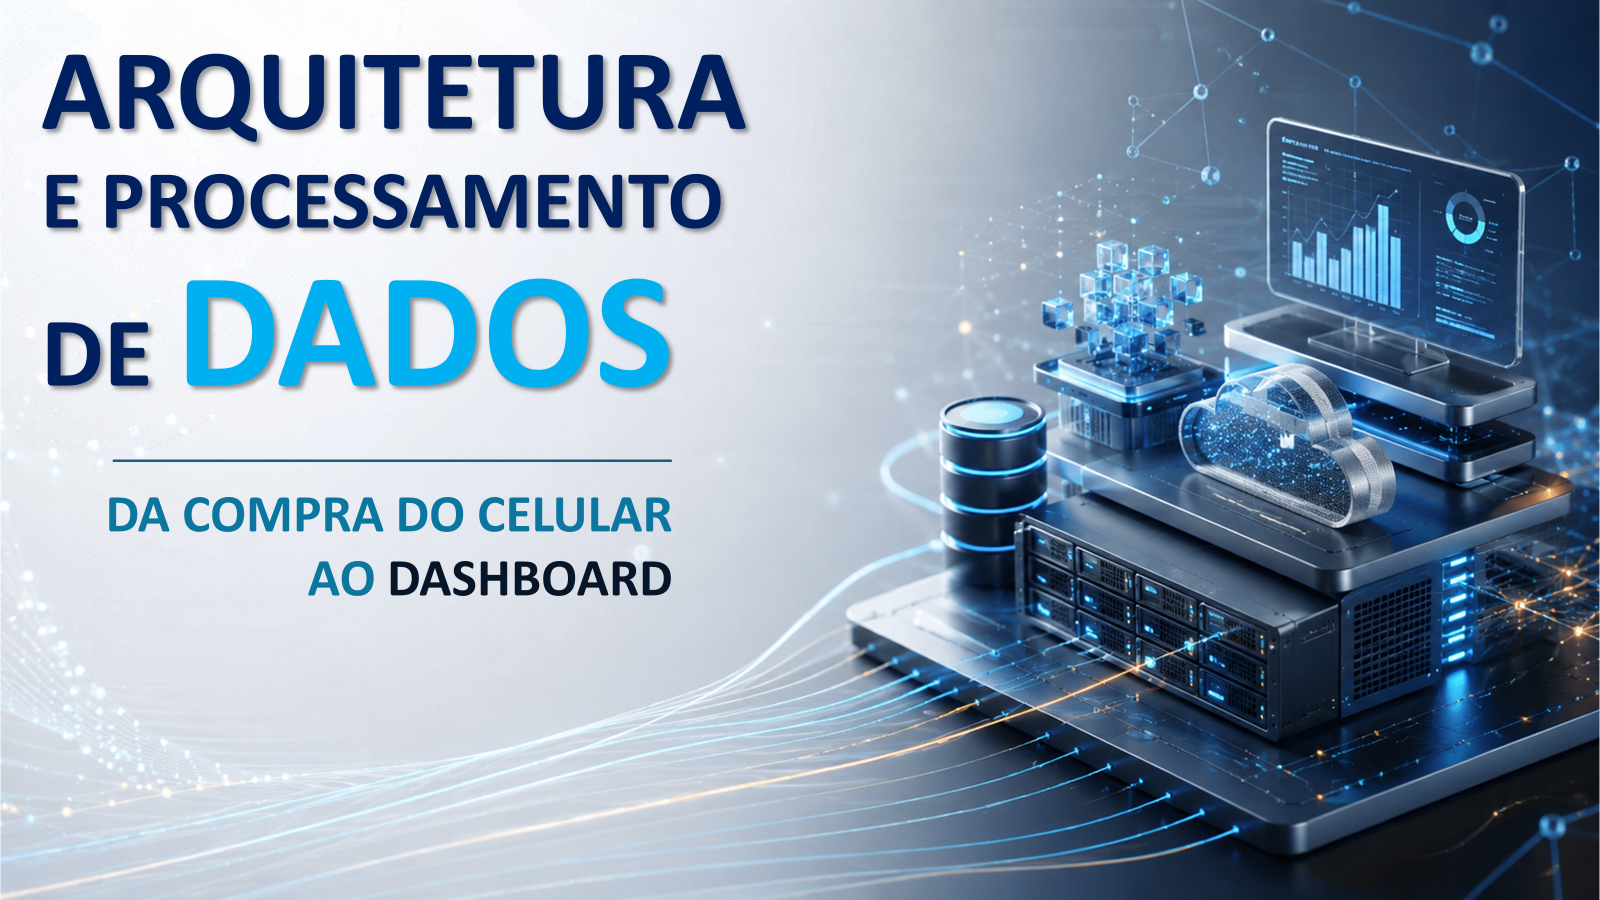

Este notebook acompanha, de forma didática, o caminho percorrido por um dado desde sua geração em um aplicativo até sua utilização em uma camada analítica. Em seguida, aprofunda a criação e o teste de APIs com FastAPI.

## Objetivos de aprendizagem

Ao final da aula, você deverá ser capaz de:

- explicar o papel de cliente, HTTP, JSON, API, banco transacional, Data Lake e camada analítica;
- definir contratos de dados e regras de validação com Pydantic;
- criar e testar endpoints `GET` e `POST` com FastAPI;
- diferenciar dados em trânsito e em repouso, além de processamento OLTP (Processamento de Transações Online) e OLAP (Processamento Analítico Online);
- construir um pipeline simples de extração, integração, transformação e análise.


## 1. Cenário

Considere uma empresa que vende produtos por um aplicativo móvel.

Quando um cliente pressiona **Finalizar compra**, o dado pode percorrer diversos componentes:

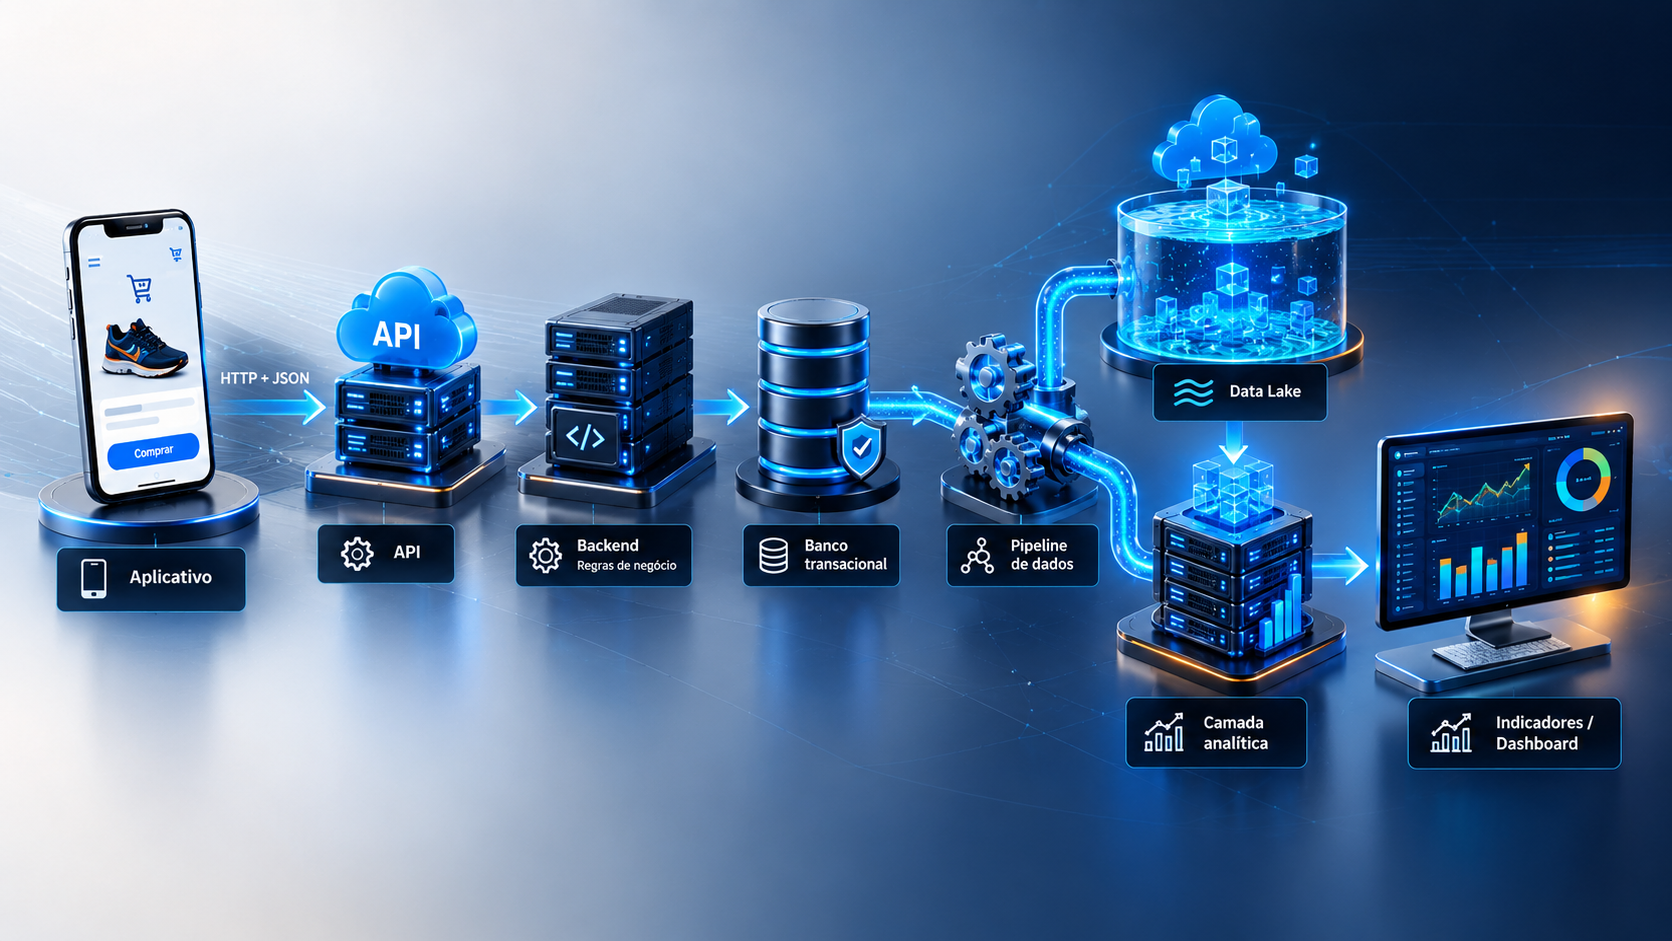


Nesta prática, utilizaremos uma arquitetura simplificada:

| Componente | Tecnologia didática |
|---|---|
| Cliente | Python |
| API | FastAPI |
| Formato de troca | JSON |
| Persistência transacional | SQLite |
| Processamento | pandas |
| Data Lake simplificado | diretórios e arquivos JSON/CSV |
| Camada analítica | pandas |
| Dashboard | matplotlib |

A implementação não representa uma arquitetura de produção. O objetivo é materializar os principais conceitos arquiteturais em um ambiente pequeno e observável.

## 2. Preparação do ambiente

Instale as bibliotecas utilizadas na atividade.

> Se o ambiente já possuir os pacotes, esta célula apenas confirmará a instalação.

In [1]:
%pip install -q fastapi uvicorn pydantic pandas matplotlib httpx 

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
from pathlib import Path  
from datetime import datetime  
import json  
import sqlite3  
import pandas as pd  
import matplotlib.pyplot as plt  
from fastapi import FastAPI, HTTPException  
from fastapi.testclient import TestClient  
from pydantic import BaseModel, Field  


c:\Users\52068085801\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


## 3. Estrutura de diretórios e reprodutibilidade

Vamos usar uma área exclusiva para esta prática:

```text
dados/api_compras.db
data_lake/compras/raw/
data_lake/compras/processed/
```

A camada `raw` preserva dados próximos da forma recebida. A camada `processed` contém dados já tratados. A célula seguinte reinicia apenas os artefatos desta prática, permitindo executar o notebook várias vezes sem conflito de chaves. Outros arquivos da pasta não são alterados.


In [2]:
Path('dados').mkdir(exist_ok=True)  # Cria o diretório quando necessário
RAW_PATH = Path('data_lake/compras/raw')  # Define ou atualiza RAW_PATH
PROCESSED_PATH = Path('data_lake/compras/processed')  # Define ou atualiza PROCESSED_PATH
RAW_PATH.mkdir(parents=True, exist_ok=True)  # Cria o diretório quando necessário
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)  # Cria o diretório quando necessário
DB_PATH = Path('dados/api_compras.db')  # Define ou atualiza DB_PATH
def conectar():  # Declara a função executada nesta etapa
    """Cria uma conexão curta com o banco transacional da aula."""  # Executa esta etapa do processamento
    return sqlite3.connect(DB_PATH)  # Devolve o resultado ao chamador
for arquivo in RAW_PATH.glob('pedido_*.json'):  # Percorre os elementos da coleção
    arquivo.unlink()  # Remove apenas o artefato anterior da prática
for arquivo in PROCESSED_PATH.glob('*.csv'):  # Percorre os elementos da coleção
    arquivo.unlink()  # Remove apenas o artefato anterior da prática


## 4. O dado nasce no aplicativo

Vamos representar uma compra como um objeto Python equivalente ao JSON enviado por um aplicativo.

Neste momento, o dado ainda está no **lado cliente**.

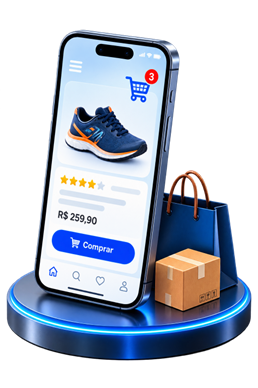


- Nesta fase, a compra está em memória localmente no dispositivo.
- Se o aplicativo for fechado antes de enviar a informação, esse dado pode nem chegar à empresa.

In [3]:
compra_exemplo = {'id_pedido': 1001, 'id_cliente': 25, 'id_produto': 501, 'quantidade': 1, 'preco_unitario': 4500.0, 'forma_pagamento': 'cartao', 'data_hora': '2026-08-12 14:32:00'}  # Define ou atualiza compra_exemplo
compra_exemplo  # Exibe compra_exemplo no notebook


{'id_pedido': 1001,
 'id_cliente': 25,
 'id_produto': 501,
 'quantidade': 1,
 'preco_unitario': 4500.0,
 'forma_pagamento': 'cartao',
 'data_hora': '2026-08-12 14:32:00'}

### Discussão

Antes do envio:

- o dado está no cliente;
- ainda não existe registro oficial no banco da empresa;
- ele pode estar apenas em memória ou em algum armazenamento local do aplicativo.

Quando a aplicação enviar esse objeto por HTTP, teremos um **dado em trânsito**.

## 5. Definindo o contrato de dados da API

Uma API não deve aceitar qualquer estrutura arbitrária. É conveniente definir um **contrato**.

A classe abaixo especifica os campos esperados em uma compra.

Isso permite:

- validar tipos;
- rejeitar requisições incorretas;
- documentar a interface;
- estabelecer um padrão de integração entre sistemas.

In [ ]:
class Compra(BaseModel):  # Define o contrato de dados
    id_pedido: int  
    id_cliente: int  
    id_produto: int  
    quantidade: int = Field(gt=0)  # Define ou atualiza quantidade: # gran then - o valor deve ser maior que zero
    preco_unitario: float = Field(gt=0)  # Define ou atualiza preco_unitario:
    forma_pagamento: str
    data_hora: datetime  


## 6. Criando o banco transacional

Vamos utilizar SQLite como representação didática de um banco operacional.

A tabela `pedidos` armazenará as transações realizadas pela aplicação.

```text
API
 │
 ▼
SQLite
```

Em um ambiente real, esse banco poderia ser PostgreSQL, MySQL, SQL Server, Oracle ou outro sistema de persistência.

In [5]:
with conectar() as conn:  # Abre o recurso e garante o fechamento automático
    conn.execute('CREATE TABLE IF NOT EXISTS pedidos ( id_pedido INTEGER PRIMARY KEY, id_cliente INTEGER NOT NULL, id_produto INTEGER NOT NULL, quantidade INTEGER NOT NULL CHECK (quantidade > 0), preco_unitario REAL NOT NULL CHECK (preco_unitario > 0), forma_pagamento TEXT NOT NULL, data_hora TEXT NOT NULL )')  # Executa o comando no banco de dados
    conn.execute('DELETE FROM pedidos')  # Executa o comando no banco de dados
    conn.commit()  # Confirma a transação no banco


## 7. Construindo a API com FastAPI

Nesta etapa criaremos uma API com três endpoints.

### O que é um endpoint?

Um endpoint é um ponto específico de acesso disponibilizado por uma API para executar determinada operação.

Podemos pensar em um endpoint como a combinação de: método HTTP + endereço (rota)

Por exemplo: **GET/pedidos** Leia-se: faça uma requisição utilizando o método GET para a rota /pedidos

Cada endpoint possui uma responsabilidade definida.

Nesta atividades teremos três endpoints:

```text
GET/         → verificar se a API está ativa
POST/pedidos → registrar uma compra
GET /pedidos → consultar compras registradas
```

O aplicativo cliente não precisa conhecer detalhes do banco. Ele se comunica com a **interface pública definida pela API**.

In [6]:
app = FastAPI(title='API de Pedidos', description='API didática para Arquitetura e Processamento de Dados', version='1.0.0')  # Define ou atualiza app
@app.get('/')  # Registra a rota e o método HTTP
def inicio():  # Declara a função executada nesta etapa
    return {'mensagem': 'API de pedidos em funcionamento'}  # Devolve o resultado ao chamador


## 8. Endpoint de criação de pedidos

O `POST/pedidos` executará três ações:

1. receber e validar o JSON;
2. registrar uma cópia do evento na área `raw`;
3. persistir a transação no SQLite.

Observe que o mesmo evento pode passar a existir em **mais de um local**, cada qual com uma finalidade distinta.

In [7]:
@app.post('/pedidos', status_code=201)  # Registra a rota e o método HTTP
def criar_pedido(compra: Compra):  # Declara a função executada nesta etapa
    dados = compra.model_dump()  # Define ou atualiza dados
    dados['data_hora'] = compra.data_hora.isoformat(sep=' ')  # Define ou atualiza dados
    try:  # Inicia o tratamento da operação protegida
        with conectar() as conn:  # Abre o recurso e garante o fechamento automático
            conn.execute('INSERT INTO pedidos ( id_pedido, id_cliente, id_produto, quantidade, preco_unitario, forma_pagamento, data_hora ) VALUES (?, ?, ?, ?, ?, ?, ?)', (dados['id_pedido'], dados['id_cliente'], dados['id_produto'], dados['quantidade'], dados['preco_unitario'], dados['forma_pagamento'], dados['data_hora']))  # Executa o comando no banco de dados
            conn.commit()  # Confirma a transação no banco
    except sqlite3.IntegrityError as erro:  # Captura uma falha prevista
        raise HTTPException(status_code=409, detail='Já existe um pedido com esse id_pedido.') from erro  # Interrompe a operação com uma resposta de erro
    arquivo_raw = RAW_PATH / f'pedido_{compra.id_pedido}.json'  # Define ou atualiza arquivo_raw
    with arquivo_raw.open('w', encoding='utf-8') as arquivo:  # Abre o recurso e garante o fechamento automático
        json.dump(dados, arquivo, ensure_ascii=False, indent=4)  # Executa esta etapa do processamento
    return {'status': 'sucesso', 'id_pedido': compra.id_pedido}  # Devolve o resultado ao chamador


## 9. Endpoint de consulta

Agora adicionaremos um endpoint `GET`.

Ele lê os pedidos registrados no banco transacional e os devolve em formato JSON.

In [8]:
@app.get('/pedidos')  # Registra a rota e o método HTTP
def listar_pedidos():  # Declara a função executada nesta etapa
    with conectar() as conn:  # Abre o recurso e garante o fechamento automático
        conn.row_factory = sqlite3.Row  # Define ou atualiza conn.row_factory
        registros = conn.execute('SELECT id_pedido, id_cliente, id_produto, quantidade, preco_unitario, forma_pagamento, data_hora FROM pedidos ORDER BY id_pedido').fetchall()  # Executa o comando no banco de dados
    return [dict(registro) for registro in registros]  # Devolve o resultado ao chamador


## 10. Testando a API dentro do notebook

Para manter a aula autocontida, utilizaremos `TestClient`.

Ele permite fazer requisições HTTP à aplicação FastAPI sem precisar abrir um servidor externo.

Conceitualmente, continuamos trabalhando com:

```text
Cliente
   │
   │ HTTP
   ▼
FastAPI
```

Posteriormente há uma seção opcional mostrando como executar a API com Uvicorn e acessá-la pelo navegador.

In [9]:
client = TestClient(app)  # Define ou atualiza client
resposta = client.get('/')  # Define ou atualiza resposta
(resposta.status_code, resposta.json())  # Executa esta etapa do processamento


(200, {'mensagem': 'API de pedidos em funcionamento'})

## 11. Simulando a compra realizada pelo celular

O cliente enviará o JSON para:

```text
POST /pedidos
```

Nesse instante, o dado está **em trânsito** entre cliente e servidor.

In [10]:
resposta = client.post('/pedidos', json=compra_exemplo)  # Define ou atualiza resposta
print('Status HTTP:', resposta.status_code)  # Exibe o resultado para conferência
print('Resposta:', resposta.json())  # Exibe o resultado para conferência


Status HTTP: 201
Resposta: {'status': 'sucesso', 'id_pedido': 1001}


### Interpretação

Depois de um `POST` bem-sucedido:



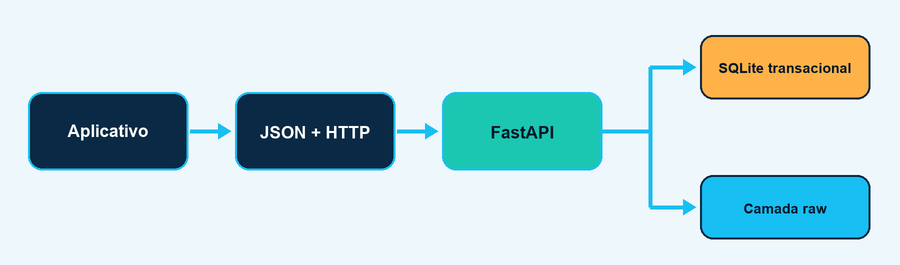


Agora o dado está **persistido**.

Temos, portanto, uma diferença importante:

- **dado em trânsito**: durante a comunicação;
- **dado em repouso**: armazenado de forma persistente.

## 12. Teste de validação

Vamos enviar uma compra inválida.

A quantidade será negativa. Como nosso contrato exige `quantidade > 0`, a API deverá rejeitar o dado.

In [11]:
compra_invalida = {'id_pedido': 9999, 'id_cliente': 25, 'id_produto': 501, 'quantidade': -2, 'preco_unitario': 4500.0, 'forma_pagamento': 'cartao', 'data_hora': '2026-08-12 14:40:00'}  # Define ou atualiza compra_invalida
resposta = client.post('/pedidos', json=compra_invalida)  # Define ou atualiza resposta
print('Status HTTP:', resposta.status_code)  # Exibe o resultado para conferência
resposta.json()  # Executa esta etapa do processamento


Status HTTP: 422


{'detail': [{'type': 'greater_than',
   'loc': ['body', 'quantidade'],
   'msg': 'Input should be greater than 0',
   'input': -2,
   'ctx': {'gt': 0}}]}

### Discussão

A validação na API é um primeiro mecanismo de controle de qualidade.

Entretanto, **qualidade de dados não se resume à validação de tipos**. Em sistemas reais, também podem existir regras como:

- produto precisa existir;
- cliente precisa estar ativo;
- estoque precisa ser suficiente;
- forma de pagamento precisa ser válida;
- preço não pode divergir do preço autorizado;
- horário precisa ser coerente.

## 13. Consultando a API

Vamos consultar os pedidos registrados.

In [12]:
resposta = client.get('/pedidos')  # Define ou atualiza resposta
print('Status HTTP:', resposta.status_code)  # Exibe o resultado para conferência
resposta.json()  # Executa esta etapa do processamento


Status HTTP: 200


[{'id_pedido': 1001,
  'id_cliente': 25,
  'id_produto': 501,
  'quantidade': 1,
  'preco_unitario': 4500.0,
  'forma_pagamento': 'cartao',
  'data_hora': '2026-08-12 14:32:00'}]

## 14. Consultando diretamente o banco

Agora faremos algo diferente: o notebook analítico acessará o SQLite com pandas.

Isso permite comparar duas formas de acesso:



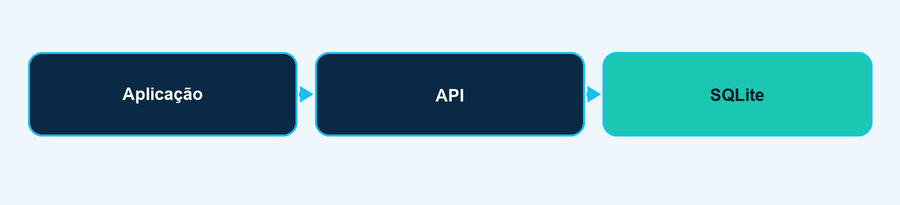


Em uma arquitetura real, o acesso direto a bancos operacionais deve ser controlado. Consultas analíticas intensas podem competir com o processamento transacional.

In [13]:
with conectar() as conn:  # Abre o recurso e garante o fechamento automático
    df_pedidos = pd.read_sql_query('SELECT * FROM pedidos ORDER BY id_pedido', conn)  # Define ou atualiza df_pedidos, ou seja, define como df_pedidos o resultado da consulta SQL
df_pedidos  # Exibe df_pedidos no notebook


,id_pedido,id_cliente,id_produto,quantidade,preco_unitario,forma_pagamento,data_hora
0,1001,25,501,1,4500.0,cartao,2026-08-12 14:32:00


## 15. Introduzindo outras fontes de dados

Uma compra isolada possui identificadores, como `id_cliente` e `id_produto`.

Para responder perguntas de negócio, precisamos adicionar contexto.

Vamos simular duas fontes adicionais:

- cadastro de clientes;
- cadastro de produtos.

In [14]:
clientes = pd.DataFrame({'id_cliente': [25, 26, 27], 'nome': ['Ana', 'Bruno', 'Carla'], 'cidade': ['São Paulo', 'Campinas', 'Santos']})  # Define ou atualiza clientes
produtos = pd.DataFrame({'id_produto': [501, 502, 503], 'produto': ['Notebook', 'Monitor', 'Teclado'], 'categoria': ['Informática', 'Informática', 'Acessórios']})  # Define ou atualiza produtos
display(clientes)  # Executa esta etapa do processamento
display(produtos)  # Executa esta etapa do processamento


,id_cliente,nome,cidade
0,25,Ana,São Paulo
1,26,Bruno,Campinas
2,27,Carla,Santos


,id_produto,produto,categoria
0,501,Notebook,Informática
1,502,Monitor,Informática
2,503,Teclado,Acessórios


## 16. Extração

A primeira etapa do pipeline é obter os dados das fontes.

Neste exemplo:

- pedidos são extraídos do SQLite;
- clientes e produtos já estão disponíveis como DataFrames.

Em sistemas reais, as fontes poderiam ser APIs, bancos SQL/NoSQL, arquivos, filas, sistemas ERP, sensores ou serviços externos.

In [15]:
with conectar() as conn:  # Abre o recurso e garante o fechamento automático
    pedidos = pd.read_sql_query('SELECT * FROM pedidos', conn)  # Define ou atualiza pedidos
pedidos  # Exibe pedidos no notebook


,id_pedido,id_cliente,id_produto,quantidade,preco_unitario,forma_pagamento,data_hora
0,1001,25,501,1,4500.0,cartao,2026-08-12 14:32:00


## 17. Integração

Agora vamos combinar os pedidos com clientes e produtos.

O `merge` representa, em pequena escala, uma operação de integração de dados.

In [16]:
dados_integrados = pedidos.merge(clientes, on='id_cliente', how='left').merge(produtos, on='id_produto', how='left')  # Define ou atualiza dados_integrados
dados_integrados  # Exibe dados_integrados no notebook


,id_pedido,id_cliente,id_produto,quantidade,preco_unitario,forma_pagamento,data_hora,nome,cidade,produto,categoria
0,1001,25,501,1,4500.0,cartao,2026-08-12 14:32:00,Ana,São Paulo,Notebook,Informática


### Antes e depois da integração

Antes:

```text
Pedido 1001
Cliente 25
Produto 501
```

Depois:

```text
Pedido 1001
Cliente: Ana
Cidade: São Paulo
Produto: Notebook
Categoria: Informática
```

A integração adiciona **contexto semântico** aos registros transacionais.

## 18. Transformação

Agora criaremos atributos úteis para análise:

- valor total da compra;
- data;
- hora.

Essa etapa representa uma transformação do dado para uso analítico.

In [17]:
dados_integrados['data_hora'] = pd.to_datetime(dados_integrados['data_hora'])  # Define ou atualiza dados_integrados
dados_integrados['valor_total'] = dados_integrados['quantidade'] * dados_integrados['preco_unitario']  # Define ou atualiza dados_integrados
dados_integrados['data'] = dados_integrados['data_hora'].dt.date  # Define ou atualiza dados_integrados
dados_integrados['hora'] = dados_integrados['data_hora'].dt.hour  # Define ou atualiza dados_integrados
dados_integrados  # Exibe dados_integrados no notebook

,id_pedido,id_cliente,id_produto,quantidade,preco_unitario,forma_pagamento,data_hora,nome,cidade,produto,categoria,valor_total,data,hora
0,1001,25,501,1,4500.0,cartao,2026-08-12 14:32:00,Ana,São Paulo,Notebook,Informática,4500.0,2026-08-12,14


## 19. Data Lake simplificado

Vamos armazenar o resultado processado em:

```text
data_lake/compras/processed/
```

A ideia é representar uma arquitetura em camadas:



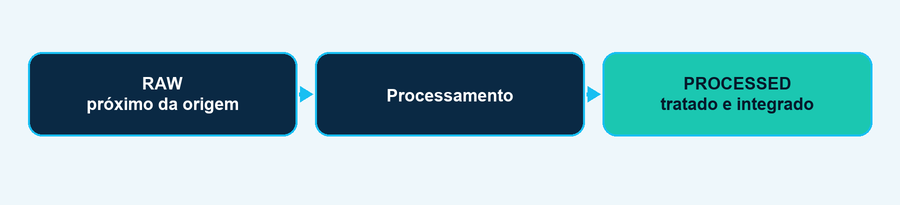


Em uma solução real, essas áreas poderiam existir em object storage ou sistemas distribuídos.

In [18]:
ARQUIVO_PROCESSADO = PROCESSED_PATH / 'vendas_integradas.csv'  # Define ou atualiza ARQUIVO_PROCESSADO
dados_integrados.to_csv(ARQUIVO_PROCESSADO, index=False)  # Grava o resultado processado em CSV
print(f'Arquivo salvo em: {ARQUIVO_PROCESSADO}')  # Exibe o resultado para conferência


Arquivo salvo em: data_lake\compras\processed\vendas_integradas.csv


## 20. Visualizando o que foi armazenado

Vamos listar os arquivos produzidos durante a atividade.

In [19]:
for caminho in sorted(Path('data_lake/compras').rglob('*')):  # Percorre os elementos da coleção
    if caminho.is_file():  # Verifica a condição antes de continuar
        print(caminho)  # Exibe o resultado para conferência


data_lake\compras\processed\vendas_integradas.csv
data_lake\compras\raw\pedido_1001.json


## 21. Criando mais transações

Para que a análise seja mais interessante, registraremos algumas compras adicionais pela própria API.

Observe que cada nova transação percorre o mesmo caminho de ingestão.

In [20]:
novas_compras = [{'id_pedido': 1002, 'id_cliente': 26, 'id_produto': 502, 'quantidade': 2, 'preco_unitario': 1800.0, 'forma_pagamento': 'pix', 'data_hora': '2026-08-12 15:10:00'}, {'id_pedido': 1003, 'id_cliente': 27, 'id_produto': 503, 'quantidade': 3, 'preco_unitario': 150.0, 'forma_pagamento': 'cartao', 'data_hora': '2026-08-12 15:25:00'}, {'id_pedido': 1004, 'id_cliente': 25, 'id_produto': 502, 'quantidade': 1, 'preco_unitario': 1800.0, 'forma_pagamento': 'pix', 'data_hora': '2026-08-12 16:05:00'}]  # Define ou atualiza novas_compras
for compra in novas_compras:  # Percorre os elementos da coleção
    resposta = client.post('/pedidos', json=compra)  # Define ou atualiza resposta
    print(compra['id_pedido'], resposta.status_code, resposta.json())  # Exibe o resultado para conferência


1002 201 {'status': 'sucesso', 'id_pedido': 1002}
1003 201 {'status': 'sucesso', 'id_pedido': 1003}
1004 201 {'status': 'sucesso', 'id_pedido': 1004}


## 22. Atualizando o pipeline

Como novas transações chegaram, precisamos executar novamente:



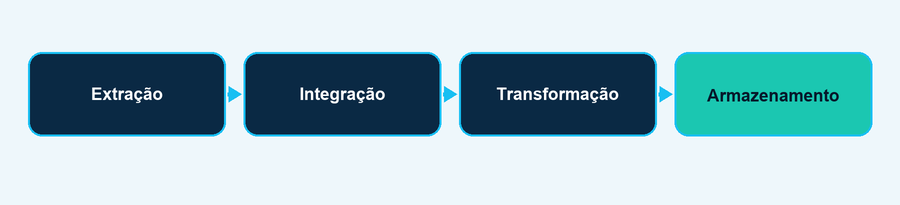


Esse encadeamento representa a lógica básica de um **pipeline de dados**.

In [21]:
with conectar() as conn:  # Abre o recurso e garante o fechamento automático
    pedidos = pd.read_sql_query('SELECT * FROM pedidos', conn)  # Define ou atualiza pedidos
dados_integrados = pedidos.merge(clientes, on='id_cliente', how='left').merge(produtos, on='id_produto', how='left')  # Define ou atualiza dados_integrados
dados_integrados['data_hora'] = pd.to_datetime(dados_integrados['data_hora'])  # Define ou atualiza dados_integrados
dados_integrados['valor_total'] = dados_integrados['quantidade'] * dados_integrados['preco_unitario']  # Define ou atualiza dados_integrados
dados_integrados['data'] = dados_integrados['data_hora'].dt.date  # Define ou atualiza dados_integrados
dados_integrados['hora'] = dados_integrados['data_hora'].dt.hour  # Define ou atualiza dados_integrados
dados_integrados.to_csv(ARQUIVO_PROCESSADO, index=False)  # Grava o resultado processado em CSV
dados_integrados  # Exibe dados_integrados no notebook


,id_pedido,id_cliente,id_produto,quantidade,preco_unitario,forma_pagamento,data_hora,nome,cidade,produto,categoria,valor_total,data,hora
0,1001,25,501,1,4500.0,cartao,2026-08-12 14:32:00,Ana,São Paulo,Notebook,Informática,4500.0,2026-08-12,14
1,1002,26,502,2,1800.0,pix,2026-08-12 15:10:00,Bruno,Campinas,Monitor,Informática,3600.0,2026-08-12,15
2,1003,27,503,3,150.0,cartao,2026-08-12 15:25:00,Carla,Santos,Teclado,Acessórios,450.0,2026-08-12,15
3,1004,25,502,1,1800.0,pix,2026-08-12 16:05:00,Ana,São Paulo,Monitor,Informática,1800.0,2026-08-12,16


## 23. Camada analítica

Agora os dados deixam de ser observados apenas como transações individuais.

Queremos responder perguntas como:

- Qual é o faturamento total?
- Quantos pedidos foram realizados?
- Qual é o ticket médio?
- Quanto foi vendido por cidade?
- Quanto foi vendido por categoria?

Aqui começamos a transição entre **processamento operacional** e **processamento analítico**.

In [22]:
faturamento_total = dados_integrados['valor_total'].sum()  # Define ou atualiza faturamento_total
numero_pedidos = dados_integrados['id_pedido'].nunique()  # Define ou atualiza numero_pedidos
ticket_medio = faturamento_total / numero_pedidos  # Define ou atualiza ticket_medio
print(f'Faturamento total: R$ {faturamento_total:,.2f}')  # Exibe o resultado para conferência
print(f'Número de pedidos: {numero_pedidos}')  # Exibe o resultado para conferência
print(f'Ticket médio: R$ {ticket_medio:,.2f}')  # Exibe o resultado para conferência


Faturamento total: R$ 10,350.00
Número de pedidos: 4
Ticket médio: R$ 2,587.50


## 24. Agregação por cidade

In [23]:
vendas_por_cidade = dados_integrados.groupby('cidade', as_index=False).agg(faturamento=('valor_total', 'sum'), pedidos=('id_pedido', 'nunique')).sort_values('faturamento', ascending=False)  # Define ou atualiza vendas_por_cidade
vendas_por_cidade  # Exibe vendas_por_cidade no notebook


,cidade,faturamento,pedidos
2,São Paulo,6300.0,2
0,Campinas,3600.0,1
1,Santos,450.0,1


## 25. Agregação por categoria

In [24]:
vendas_por_categoria = dados_integrados.groupby('categoria', as_index=False).agg(faturamento=('valor_total', 'sum'), pedidos=('id_pedido', 'nunique')).sort_values('faturamento', ascending=False)  # Define ou atualiza vendas_por_categoria
vendas_por_categoria  # Exibe vendas_por_categoria no notebook


,categoria,faturamento,pedidos
1,Informática,9900.0,3
0,Acessórios,450.0,1


## 26. Um dashboard simples

O objetivo aqui não é ensinar visualização de dados em profundidade.

O gráfico apenas representa o último estágio do fluxo:



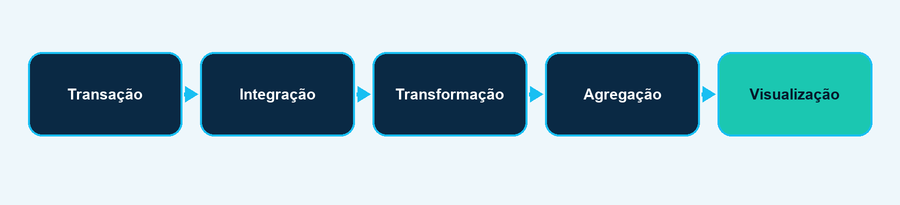


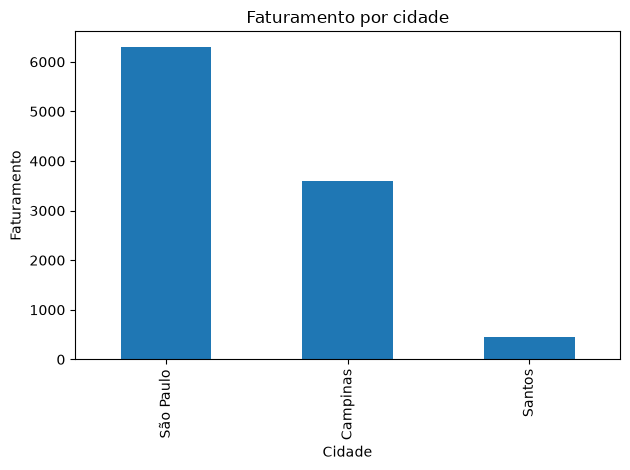

In [25]:
ax = vendas_por_cidade.plot(x='cidade', y='faturamento', kind='bar', legend=False)  # Configura ou exibe a visualização
ax.set_title('Faturamento por cidade')  # Configura ou exibe a visualização
ax.set_xlabel('Cidade')  # Configura ou exibe a visualização
ax.set_ylabel('Faturamento')  # Configura ou exibe a visualização
plt.tight_layout()  # Configura ou exibe a visualização
plt.show()  # Configura ou exibe a visualização


## 27. Reconstruindo a arquitetura completa

Depois de executar a prática, podemos descrever o caminho percorrido por uma compra:



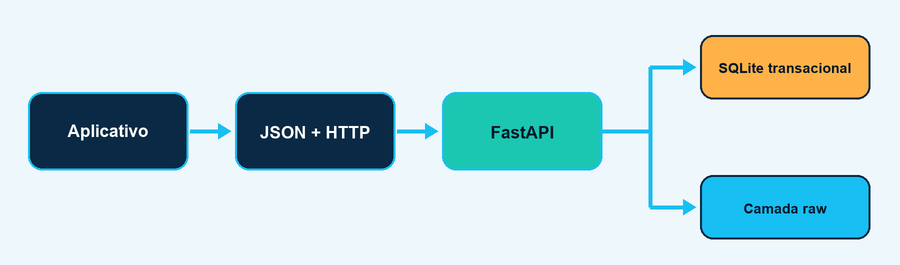


## 28. O que cada componente fez?

| Componente | Papel na arquitetura |
|---|---|
| Cliente | gera a interação e envia a compra |
| JSON | representa o formato de troca |
| HTTP | transporta a requisição |
| API | define a interface de integração |
| Pydantic | valida o contrato de dados |
| SQLite | persiste a transação operacional |
| Data Lake RAW | preserva uma representação próxima ao dado de origem |
| pandas | extrai, integra, transforma e agrega |
| Data Lake PROCESSED | guarda dados preparados |
| matplotlib | representa o consumo analítico |

> **Arquitetura de Dados não é um único banco de dados. É a organização dos componentes e fluxos responsáveis por mover, persistir, transformar e disponibilizar os dados.**

## 29. OLTP e OLAP: primeira aproximação

Ainda que esses conceitos sejam aprofundados posteriormente, a prática já permite uma distinção inicial.

### Processamento transacional

O SQLite foi utilizado para registrar pedidos individuais:

```text
registrar pedido
consultar pedido
persistir compra
```

Esse comportamento se aproxima de uma carga **OLTP**.

### Processamento analítico

As operações realizadas com pandas foram orientadas a perguntas agregadas:

```text
faturamento total
ticket médio
vendas por cidade
vendas por categoria
```

Esse comportamento se aproxima de uma carga **OLAP**.

Em arquiteturas reais, ambientes transacionais e analíticos frequentemente são separados porque possuem objetivos e padrões de carga distintos.

## 30. Por que não conectar o aplicativo diretamente ao banco?

Compare:



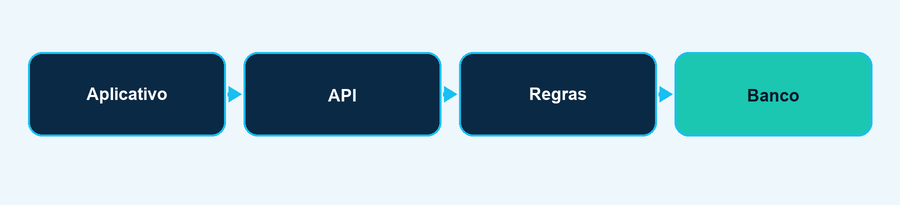


com:



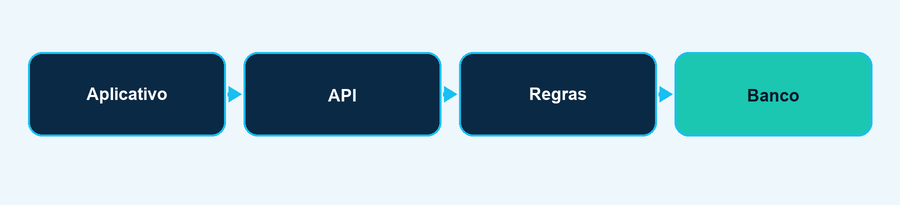


A segunda arquitetura permite introduzir mecanismos como:

- validação;
- autenticação;
- autorização;
- regras de negócio;
- controle de acesso;
- versionamento;
- auditoria;
- desacoplamento entre cliente e persistência.

A API funciona como uma **interface arquitetural**, e não como o local definitivo de armazenamento.

## 31. Limitações da arquitetura didática e evolução para produção

O notebook usa um único processo, SQLite e arquivos locais porque essa combinação deixa cada etapa visível. Em produção, volume, concorrência e falhas exigem outros mecanismos.

### Escala e disponibilidade

Com milhões de compras por dia, uma única instância se torna um ponto de saturação e de falha. Uma evolução possível inclui várias instâncias da API atrás de um balanceador, mensageria durável para absorver picos, banco com replicação e particionamento, além de processamento incremental. Escalar significa distribuir trabalho sem perder controle sobre o estado.

### Atomicidade e concorrência

Uma operação **atômica** acontece por completo ou não deixa efeito parcial. Ao vender o último item, reduzir o estoque e registrar o pedido devem formar uma única transação lógica. O banco pode usar transações, bloqueios, controle de versão ou uma atualização condicional como `UPDATE ... WHERE estoque > 0`.

> **Analogia:** em uma transferência bancária, retirar o valor de uma conta e depositá-lo em outra não pode parar no meio.

### Idempotência

Uma operação **idempotente** pode ser repetida sem criar efeitos adicionais indesejados. Se o celular não receber a resposta e reenviar a compra, uma chave idempotente permite reconhecer a tentativa anterior e devolver o mesmo resultado sem cobrar ou cadastrar duas vezes.

> **Analogia:** apertar duas vezes o botão do elevador não deveria solicitar dois elevadores para o mesmo chamado.

### Segurança, observabilidade e recuperação

Uma arquitetura de produção também precisa de autenticação, autorização, criptografia, gestão de segredos, limites de requisição, logs estruturados, métricas, rastreamento, alertas, backups testados e um plano de recuperação. Esses controles ajudam a responder não apenas **se** ocorreu uma falha, mas **onde**, **quando** e **qual foi o impacto**.

### Questões para discussão

- Em quais partes do sistema a consistência precisa ser imediata?
- Onde a consistência eventual seria aceitável?
- Como confirmar que uma compra foi processada quando a resposta da API se perde?
- Qual componente deve ser a fonte oficial para estoque, pagamento e indicadores?


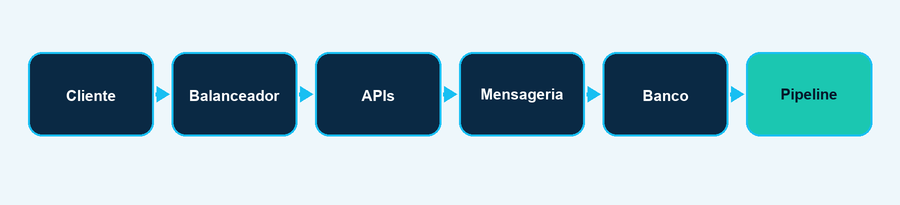


# Parte II — Prática guiada: API de produtos em memória

Esta segunda implementação isola os fundamentos da criação de endpoints. Diferentemente da API de pedidos, ela armazena dados apenas em uma lista Python: ao reiniciar o kernel, os produtos desaparecem. A comparação evidencia por que persistência e arquitetura são decisões diferentes da interface HTTP.


## P2.1 — Criando o modelo de dados

Cada produto terá:

- `id_produto`: identificador numérico;
- `nome`: nome do produto;
- `preco`: preço unitário;
- `estoque`: quantidade disponível.

O Pydantic será utilizado para validar os dados recebidos pela API.


In [26]:
class Produto(BaseModel):  # Define o contrato de dados
    id_produto: int  # Executa esta etapa do processamento
    nome: str  # Executa esta etapa do processamento
    preco: float = Field(gt=0)  # Define ou atualiza preco:
    estoque: int = Field(ge=0)  # Define ou atualiza estoque:


## P2.2 — Criando a aplicação FastAPI

Agora criaremos a aplicação.

Os parâmetros `title`, `description` e `version` serão utilizados também na documentação automática da API.


In [27]:
app_produtos = FastAPI(title='API de Produtos', description='API simples para prática de criação de endpoints', version='1.0.0')  # Define ou atualiza app_produtos


## P2.3 — Criando o primeiro endpoint

O primeiro endpoint servirá apenas para verificar se a API está funcionando.

```text
GET /
```


In [28]:
@app_produtos.get('/')  # Registra a rota e o método HTTP
def inicio():  # Declara a função executada nesta etapa
    return {'mensagem': 'API de produtos em funcionamento'}  # Devolve o resultado ao chamador


## P2.4 — Criando uma estrutura para armazenar os produtos

Nesta prática, não utilizaremos banco de dados.

Os produtos serão armazenados temporariamente em uma lista Python.


In [29]:
catalogo_produtos = []  # Define ou atualiza catalogo_produtos


## P2.5 — Criando o endpoint POST

O método `POST` será utilizado para cadastrar um novo produto.

O cliente enviará um JSON semelhante a:

```json
{
    "id_produto": 1,
    "nome": "Notebook",
    "preco": 3500.0,
    "estoque": 10
}
```

O FastAPI receberá esses dados e o Pydantic fará a validação.


In [30]:
@app_produtos.post('/produtos', status_code=201)  # Registra a rota e o método HTTP
def criar_produto(produto: Produto):  # Declara a função executada nesta etapa
    dados = produto.model_dump()  # Define ou atualiza dados
    catalogo_produtos.append(dados)  # Adiciona o registro à coleção em memória
    return {'status': 'produto cadastrado', 'id_produto': produto.id_produto}  # Devolve o resultado ao chamador


## P2.6 — Criando o endpoint GET para listar produtos

O endpoint abaixo retornará todos os produtos cadastrados.

```text
GET /produtos
```


In [31]:
@app_produtos.get('/produtos')  # Registra a rota e o método HTTP
def listar_produtos():  # Declara a função executada nesta etapa
    return catalogo_produtos  # Devolve o resultado ao chamador


## P2.7 — Criando um endpoint com parâmetro de rota

Agora criaremos uma rota que permite consultar um produto específico.

Exemplo:

```text
GET /produtos/1
```

Nesse caso, `1` corresponde ao identificador do produto.


In [32]:
@app_produtos.get('/produtos/{id_produto}')  # Registra a rota e o método HTTP
def buscar_produto(id_produto: int):  # Declara a função executada nesta etapa
    for produto in catalogo_produtos:  # Percorre os elementos da coleção
        if produto['id_produto'] == id_produto:  # Verifica a condição antes de continuar
            return produto  # Devolve o resultado ao chamador
    raise HTTPException(status_code=404, detail='Produto não encontrado.')  # Interrompe a operação com uma resposta de erro


## P2.8 — Criando o cliente de teste

O `TestClient` permite testar a API diretamente no notebook, sem iniciar o Uvicorn.


In [33]:
client_produtos = TestClient(app_produtos)  # Define ou atualiza client_produtos


## P2.9 — Testando o endpoint raiz

Faça uma requisição `GET` para verificar se a API está funcionando.


In [34]:
resposta = client_produtos.get('/')  # Define ou atualiza resposta
print('Status HTTP:', resposta.status_code)  # Exibe o resultado para conferência
print('Resposta:', resposta.json())  # Exibe o resultado para conferência


Status HTTP: 200
Resposta: {'mensagem': 'API de produtos em funcionamento'}


## P2.10 — Cadastrando o primeiro produto

Crie um dicionário Python e envie os dados para o endpoint `POST /produtos`.


In [35]:
produto_1 = {'id_produto': 1, 'nome': 'Notebook', 'preco': 3500.0, 'estoque': 10}  # Define ou atualiza produto_1
resposta = client_produtos.post('/produtos', json=produto_1)  # Define ou atualiza resposta
print('Status HTTP:', resposta.status_code)  # Exibe o resultado para conferência
print('Resposta:', resposta.json())  # Exibe o resultado para conferência


Status HTTP: 201
Resposta: {'status': 'produto cadastrado', 'id_produto': 1}


## P2.11 — Cadastrando um segundo produto

Agora registre outro produto.


In [36]:
produto_2 = {'id_produto': 2, 'nome': 'Mouse', 'preco': 120.0, 'estoque': 25}  # Define ou atualiza produto_2
resposta = client_produtos.post('/produtos', json=produto_2)  # Define ou atualiza resposta
print('Status HTTP:', resposta.status_code)  # Exibe o resultado para conferência
print('Resposta:', resposta.json())  # Exibe o resultado para conferência


Status HTTP: 201
Resposta: {'status': 'produto cadastrado', 'id_produto': 2}


## P2.12 — Consultando todos os produtos

Utilize o endpoint:

```text
GET /produtos
```


In [37]:
resposta = client_produtos.get('/produtos')  # Define ou atualiza resposta
print('Status HTTP:', resposta.status_code)  # Exibe o resultado para conferência
resposta.json()  # Executa esta etapa do processamento


Status HTTP: 200


[{'id_produto': 1, 'nome': 'Notebook', 'preco': 3500.0, 'estoque': 10},
 {'id_produto': 2, 'nome': 'Mouse', 'preco': 120.0, 'estoque': 25}]

## P2.13 — Consultando um produto específico

Agora utilize o identificador do produto diretamente na URL.


In [38]:
resposta = client_produtos.get('/produtos/1')  # Define ou atualiza resposta
print('Status HTTP:', resposta.status_code)  # Exibe o resultado para conferência
resposta.json()  # Executa esta etapa do processamento


Status HTTP: 200


{'id_produto': 1, 'nome': 'Notebook', 'preco': 3500.0, 'estoque': 10}

## P2.14 — Testando um produto inexistente

Consulte um identificador que ainda não foi cadastrado.

Observe o código HTTP retornado.


In [40]:
resposta = client_produtos.get('/produtos/2')  # Define ou atualiza resposta
print('Status HTTP:', resposta.status_code)  # Exibe o resultado para conferência
print('Resposta:', resposta.json())  # Exibe o resultado para conferência


Status HTTP: 200
Resposta: {'id_produto': 2, 'nome': 'Mouse', 'preco': 120.0, 'estoque': 25}


## P2.15 — Testando a validação do Pydantic

O campo `preco` foi definido com:

```python
Field(gt=0)
```

Portanto, preços iguais ou menores que zero não devem ser aceitos.


In [43]:
produto_invalido = {'id_produto': 3, 'nome': 'Teclado', 'preco': -50.0, 'estoque': 10}  # Define ou atualiza produto_invalido
resposta = client_produtos.post('/produtos', json=produto_invalido)  # Define ou atualiza resposta
print('Status HTTP:', resposta.status_code)  # Exibe o resultado para conferência
print('Resposta:', resposta.json())  # Exibe o resultado para conferência


Status HTTP: 422
Resposta: {'detail': [{'type': 'greater_than', 'loc': ['body', 'preco'], 'msg': 'Input should be greater than 0', 'input': -50.0, 'ctx': {'gt': 0.0}}]}


## P2.16 — Interpretando os principais códigos HTTP observados

Nesta prática, foram utilizados alguns códigos importantes:

| Código | Significado |
|---|---|
| `200` | Requisição executada com sucesso |
| `201` | Novo recurso criado com sucesso |
| `404` | Recurso solicitado não encontrado |
| `422` | Dados enviados não passaram pela validação |

O código HTTP informa ao cliente o resultado da operação realizada pela API.


## P2.17 — Fluxo construído

A arquitetura desta prática pode ser representada de forma simplificada:



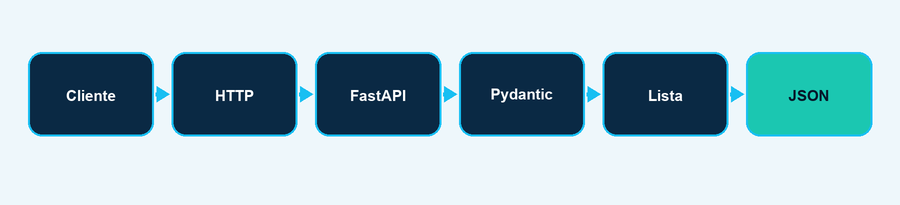


Nesta versão, a lista Python está substituindo temporariamente um banco de dados.


# Parte III — Exercícios

Execute as partes I e II antes de iniciar. Os exercícios combinam implementação, teste, análise e decisões arquiteturais. Nas questões abertas, justifique suas escolhas: respostas diferentes podem ser válidas quando bem fundamentadas.


## Exercício 1 — Nova compra e rastreabilidade

Envie pela API o pedido `1005` abaixo. Verifique o código HTTP, localize o registro no SQLite e confirme a existência do arquivo na camada `raw`. Explique em quais pontos da arquitetura o mesmo evento passou a existir.

```python
{
    "id_pedido": 1005,
    "id_cliente": 26,
    "id_produto": 503,
    "quantidade": 4,
    "preco_unitario": 150.00,
    "forma_pagamento": "pix",
    "data_hora": "2026-08-12 17:10:00"
}
```


In [44]:
nova_compra = {'id_pedido': 1005, 'id_cliente': 26, 'id_produto': 503, 'quantidade': 4, 'preco_unitario': 150.0, 'forma_pagamento': 'pix', 'data_hora': '2026-08-12 17:10:00'}  # Define ou atualiza nova_compra


## Exercício 2 — Endpoint com parâmetro de rota

Implemente `GET /pedidos/{id_pedido}`. O endpoint deve retornar um objeto JSON quando o pedido existir e responder com HTTP `404` quando não existir. Teste os pedidos `1001` e `99999`.


In [ ]:
@app.get('/pedidos/{id_pedido}')
def buscar_pedido(id_pedido: int):
    with conectar() as conn:
        conn.row_factory = sqlite3.Row
        registro = conn.execute(
            'SELECT * FROM pedidos WHERE id_pedido = ?',
            (id_pedido,)
        ).fetchone()

    if registro is None:
        raise HTTPException(
            status_code=404,
            detail='Pedido não encontrado.'
        )

    return dict(registro)

In [54]:
resposta = client.get('/pedidos/1001')
print(resposta.status_code)
print(resposta.json())

resposta = client.get('/pedidos/99999')
print(resposta.status_code)
print(resposta.json())

200
{'id_pedido': 1001, 'id_cliente': 25, 'id_produto': 501, 'quantidade': 1, 'preco_unitario': 4500.0, 'forma_pagamento': 'cartao', 'data_hora': '2026-08-12 14:32:00'}
404
{'detail': 'Pedido não encontrado.'}


## Exercício 3 — API de alunos

Crie uma terceira aplicação FastAPI para alunos. Cada aluno deve possuir `id_aluno`, `nome`, `curso` e `semestre > 0`. Implemente:

```text
POST /alunos
GET  /alunos
GET  /alunos/{id_aluno}
```

Rejeite identificadores duplicados com HTTP `409`. Cadastre dois alunos e teste também um semestre igual a zero e uma consulta inexistente.


In [ ]:
app = FastAPI(title='API de Pedidos', description='API didática para Arquitetura e Processamento de Dados', version='1.0.0')  # Define ou atualiza app
@app.get('/')  # Registra a rota e o método HTTP
def inicio():  # Declara a função executada nesta etapa
    return {'mensagem': 'API de pedidos em funcionamento'}  # Devolve o resultado ao chamador

In [56]:
app_alunos = FastAPI()
class aluno(BaseModel):
    id_aluno: int
    nome: str
    idade: int
    curso: str
    semestre: int = Field(gt=0)
catalogo_alunos = []

In [57]:
@app_alunos.post('/alunos')
def cadastrar_aluno(aluno: Aluno):
    for aluno_cadastrado in catalogo_alunos:
        if aluno_cadastrado.id_aluno == aluno.id_aluno:
            raise HTTPException(
                status_code=409,
                detail='Aluno já cadastrado.'
            )

    catalogo_alunos.append(aluno)

    return aluno

## Exercício 4 — Atualização do pipeline analítico

Depois de cadastrar o pedido `1005`, refaça a extração, integração e transformação. Calcule o faturamento por forma de pagamento e grave o resultado em `data_lake/compras/processed/faturamento_por_pagamento.csv`.


In [45]:
# Sua solução do Exercício 4

## Exercício 5 — Visualização complementar

Utilize o resultado `faturamento_por_pagamento` produzido no exercício anterior e crie um **gráfico de barras horizontal**. O gráfico deve apresentar título, nomes dos eixos, valores nas barras e uma ordenação que facilite a comparação entre as formas de pagamento.

Depois, registre uma frase interpretando o resultado observado.


In [46]:
# Sua solução do Exercício 5

## Exercício 6 — Escala, disponibilidade e consistência

Considere 10 milhões de compras por dia e apenas uma unidade de um produto disputada por dois clientes. Discuta:

- por que SQLite e um único processo deixam de ser suficientes;
- como escalar API, mensageria, armazenamento e processamento;
- como impedir venda duplicada sob concorrência;
- quais mecanismos de observabilidade, segurança e recuperação seriam necessários.


### Sua análise

Escreva aqui.
